<h1 align="center">Workshop 2: Nonsense correlations from slow fluctuations</h1>
<h3 align="center">Summer Workshop on the Dynamic Brain</h3>
<h4 align="center">Thursday, August 27th, 2026</h4>
<h4 align="center">Day 4</h4>

---

**Authors:** Nick Steinmetz, Carrie Stine

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto;">

## Introduction

Neurons fluctuate slowly. Even with no stimulus and no task event, firing rates drift up and down over tens of seconds. So do behavioral signals like pupil diameter and running speed. When two slow signals share the same recording session, they will appear correlated even if neither caused the other. This is the **nonsense correlation** problem, and it shows up in almost every large-scale recording dataset, including the Dynamic Routing data we saw earlier this week. `TO DO: insert link to dyanmic routing section of databook`

How well do standard safeguards (shuffling trials, k-fold cross-validation) perform when our data has a slowly-varying task variable and slow neural drift?

In this workshop we will build the problem from scratch in simulation (where we know the ground truth), identify which controls fail and why, and derive the ones that actually work. We then apply the same pipeline to a real Dynamic Routing session to see the artifact and the appropriate controls on real data.

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

## Learning Objectives

By the end of this workshop you will be able to:

1. **Simulate** a null hypothesis data set to test the validity of different analysis workflows.
2. **Recognise** the slow-fluctuation pitfall: why two slow, unrelated signals appear correlated.
3. **Identify** which standard controls fail or succeed.
4. **Apply** two controls that work for pupil-type correlations.
5. **Understand** the concept of *effective N* and how autocorrelation inflates false-positive rates.
6. **Apply** pseudosession and leave-one-block-out cross-validation for block-variable decoding.
7. **Demonstrate** all of these principles on real Dynamic Routing data.

</div>


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

## 0. Setup

Run this cell first. It imports every package used in this notebook. By now you should be familiar with `numpy`, `matplotlib`, and `scipy`. Some new packages that you may not have used yet:
- `sklearn`: abbreviated from scikit-learn, Python's standard machine learning library. Here we import two tools from `sklearn`:
    - **LDA (Linear Discriminant Analysis)**: used for neural decoding
    - **KFold**: used to split data into training and test sets for cross-validation
- `rastermap`: used to sort neurons by similarity in their activity patterns
- `ipympl`: used to make matplotlib figures into an interactive widget inside Jupyter
- `logging`: Python standard library for controlling log outputs; used here to prevent `rastermap` messages from cluttering cell output


</div>


In [2]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import KFold
from rastermap import Rastermap
import logging

logging.getLogger('rastermap').setLevel(logging.WARNING)

# Global figure settings
plt.rcParams['font.family']       = 'sans-serif'
plt.rcParams['font.sans-serif']   = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42


## Part 1 — Simulated Data


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

## 1. Simulate a Session

Imagine an experiment where we will record from a population of slowly fluctuating neurons during a task that alternates between two conditions or **blocks**, which we will call +1 or -1. Each block consists of roughly 30-70 trials, and the full session lasts about 500 trials. Alongside the neural recording, we are also tracking the animal's pupil diameter as a measure of arousal.

Suppose we want to understand whether neurons in our area of interest are modulated by the animal's arousal state, which we track via pupil diameter. We record from 100 neurons across a session, measure pupil diameter trial by trial, and create an analysis workflow that we believe will identify which neurons have firing rates that correlate with pupil size.

If we apply our analysis on real data and find an effect, is that a real result? Or is it an artifact of how we set up the analysis? 

This is where **simulated data** becomes invaluable. We can build a synthetic dataset that captures the key statistical features of a real session, but where we know that there is *no true effect*, to determine if our analysis workflow has an acceptable false positive rate. 

We will first build a **completely synthetic dataset** in which we know the ground truth:
the neurons have *no* relationship to either the pupil or the task block variable. Our simulated dataset contains 100 neurons whose firing rates fluctuate slowly (25 s timescale) around their own mean rate, with spike trains drawn as an inhomogeneous Poisson process. The pupil trace has a similar slow structure (20 s timescale). 

### Key parameters

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `N_NEURONS` | 100 | number of simulated neurons |
| `N_BLOCKS` | 10 | task blocks per session |
| `TRIAL_DUR` | 1.0 s | duration of one trial |
| `FLUCT_TAU` | 25 s | **timescale of each neuron's slow rate fluctuation** |
| `PUPIL_TAU` | 20 s | timescale of the pupil fluctuation |
| `RATE_BASE` | 2–9 spikes/s | each neuron's mean firing rate |
| `RATE_AMP` | 2.5 spikes/s | SD of the slow fluctuation |

The critical parameter is `FLUCT_TAU`. When it is much longer than one trial but
comparable to a task block, both the neural rates and the pupil wander on the same
timescale — producing apparent correlations even though neither caused the other.

</div>


In [1]:
SEED        = 7            # master random seed — keep this fixed to reproduce figures

N_NEURONS   = 100
N_BLOCKS    = 10           # task blocks in the session
BLOCK_LEN   = (30, 70)     # trials per block, drawn uniformly (inclusive)
TRIAL_DUR   = 1.0          # s, duration of one trial
DT          = 0.005        # s, resolution at which spikes are generated (5 ms bins)

FLUCT_TAU   = 25.0         # s, timescale of each neuron's slow rate fluctuation
PUPIL_TAU   = 20.0         # s, timescale of the pupil fluctuation
RATE_BASE   = (2.0, 9.0)   # spikes/s, each neuron's mean rate (drawn uniformly)
RATE_AMP    = 2.5          # spikes/s, SD of the slow fluctuation around that mean
TP_NOISE_SD = 0.0          # extra independent noise (0 = Poisson noise only)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

### Helper functions

`slow_traces` generates smoothed random signals by low-pass filtering white noise
with a Gaussian kernel of width `tau_pts` samples, then z-scoring each row.
The `mode='wrap'` flag makes each trace **periodic**.

`make_blocks` produces a sequence of alternating +1/−1 blocks with random lengths,
mimicking how a task block variable might be structured in a real experiment.

</div>


In [3]:
def slow_traces(rng, n_rows, n_pts, tau_pts):
    """n_rows independent smooth random traces, length n_pts, timescale tau_pts samples.
    White noise low-pass filtered with a Gaussian, then z-scored row-wise.
    mode='wrap' makes each trace periodic, so a circular shift is still a valid
    sample from the same generative process."""
    z = gaussian_filter1d(rng.normal(0, 1, (n_rows, n_pts)), tau_pts, axis=1, mode='wrap')
    return z / z.std(axis=1, keepdims=True)


def make_blocks(rng, n_blocks=N_BLOCKS, lo=BLOCK_LEN[0], hi=BLOCK_LEN[1], n_trials=None):
    """Sequence of alternating +1/−1 blocks, random lengths in [lo, hi].
    Pass n_trials to draw exactly that many trials (used for pseudosessions)."""
    sign = rng.choice([-1, 1])
    values, ids, i = [], [], 0
    while (len(values) < n_trials) if n_trials else (i < n_blocks):
        L = int(rng.integers(lo, hi + 1))
        values += [sign * (-1) ** i] * L
        ids    += [i] * L
        i += 1
    values, ids = np.array(values), np.array(ids)
    return (values[:n_trials], ids[:n_trials]) if n_trials else (values, ids)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

### Build the simulated data

We will now build the full simulated dataset in three steps.

1. **Task structure**: `make_blocks` generates the sequence of +1/−1 block labels for every trial — this is the task variable we will later try to decode. From this we also compute two useful numbers: `n_trials` (how many trials the session has) and `per_trial` (how many 5 ms time bins fit in one trial).

2. **Neural activity**: each neuron is assigned a random baseline firing rate drawn uniformly between 2 and 9 spikes/s, then a slow fluctuation is added on top. The fluctuation is a smooth random trace with a ~25 second timescale. The rates are then interpolated onto the fine 5 ms time grid and spikes are drawn bin-by-bin from a Poisson distribution. The result is a **matrix of spike counts with shape (neurons × timepoints)**.

3. **Pupil diameter**: The pupil trace is generated the same way, but on a ~20 second timescale. It is drawn after the neurons and shares no information with them. 

</div>


In [4]:
rng = np.random.default_rng(SEED)

# --- the task variable: alternating +/-1 blocks
block_values, block_ids = make_blocks(rng)
n_trials  = len(block_values)
per_trial = int(round(TRIAL_DUR / DT))        # timepoints in one trial
n_pts     = n_trials * per_trial              # timepoints in the session

# --- each neuron's firing rate: mean rate + slow fluctuation
# Nothing here depends on block_values or on the pupil.
rate_trial = (rng.uniform(*RATE_BASE, size=N_NEURONS)[:, None]
              + RATE_AMP * slow_traces(rng, N_NEURONS, n_trials, FLUCT_TAU / TRIAL_DUR))
rate_trial = rate_trial + rng.normal(0, TP_NOISE_SD, rate_trial.shape) # noise is 0 by default
rate_trial = np.clip(rate_trial, 0, None)     # firing rate cannot be negative

# --- interpolate to the fine time grid and draw Poisson spikes: independently in each
# 5 ms bin, the number of spikes is Poisson with mean rate * DT. 
t_trial = (np.arange(n_trials) + 0.5) * TRIAL_DUR   # trial centres (s)
t_pts   = np.arange(n_pts) * DT                     # fine time grid (s)
rate    = np.array([np.interp(t_pts, t_trial, r) for r in rate_trial])   # spikes/s
spikes  = rng.poisson(rate * DT)              # shape: (neurons, timepoints)

# --- pupil diameter: same kind of slow trace, independent of everything
pupil = 0.5 + 0.15 * slow_traces(rng, 1, n_trials, PUPIL_TAU / TRIAL_DUR)[0]

print(f'{N_NEURONS} neurons, {n_trials} trials ({n_trials*TRIAL_DUR/60:.1f} min), {N_BLOCKS} blocks')
print(f'Firing rates: {rate.min():.1f} – {rate.max():.1f} spikes/s (mean {rate.mean():.1f})')
print(f'{spikes.sum():,} spikes total')


100 neurons, 511 trials (8.5 min), 10 blocks
Firing rates: 0.0 – 17.3 spikes/s (mean 5.3)
272,746 spikes total


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto;">

### Exercise 1: Getting oriented with the simulation

The simulation just printed some summary statistics. Answer these questions:

1. How many trials were generated? (Hint: print `n_trials`)
2. What is the shape of `spikes`? What do the two dimensions represent?
3. How many blocks were in the session? How long was each block on average (in trials)?
4. Are any of the neurons generated using information about `block_values` or `pupil`?
   Look at the code above — this is a key point!

</div>


In [5]:
# Your code here
# Hint: n_trials, spikes.shape, len(block_values)

# 1. How many trials were generated?
print(f'Number of trials: {n_trials}')

# 2. What is the shape of spikes?
print(f'Shape of spikes: {spikes.shape}')
print('Dimensions: (neurons, timepoints) — one row per neuron, one column per 5 ms bin')

# 3. How many blocks, and what is the average block length?
n_blocks = len(np.unique(block_ids))
print(f'Number of blocks: {n_blocks}')
print(f'Average block length: {n_trials / n_blocks:.0f} trials')

# 4. Are neurons generated using block_values or pupil?
# No — inspect the code: rate_trial is built from rng.uniform() and slow_traces() only.
# Neither block_values nor pupil appear anywhere in its construction.
print('Neurons generated using block_values or pupil: False')

Number of trials: 511
Shape of spikes: (100, 102200)
Dimensions: (neurons, timepoints) — one row per neuron, one column per 5 ms bin
Number of blocks: 10
Average block length: 51 trials
Neurons generated using block_values or pupil: False


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

## 2. Spike Rasters

A **raster plot** shows every spike as a tick mark, with neurons on the y-axis
and time on the x-axis. Here we show the first 60 s (60 trials) for 12 neurons.

</div>


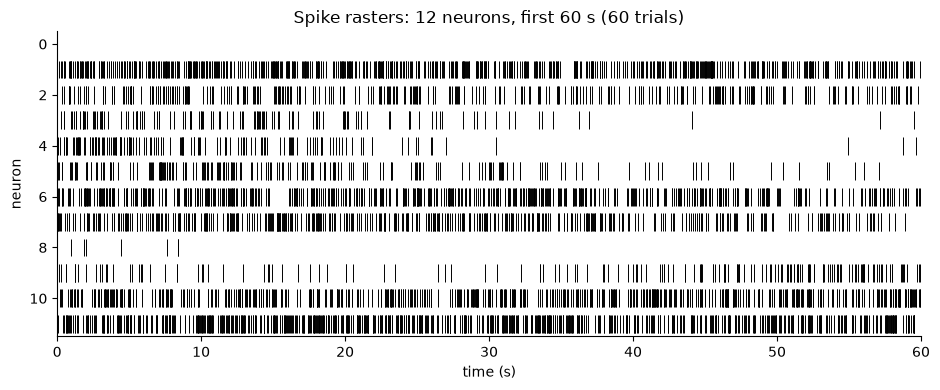

In [6]:
N_SHOW, T_SHOW = 12, 60      # neurons and seconds to display

fig, ax = plt.subplots(figsize=(9.5, 4))
times = [np.repeat(t_pts, spikes[i]) for i in range(N_SHOW)]
ax.eventplot([t[t <= T_SHOW] for t in times], colors='k', linewidths=0.7,
             lineoffsets=np.arange(N_SHOW), linelengths=0.7)
ax.set_xlim(0, T_SHOW)
ax.set_ylim(N_SHOW - 0.5, -0.5)
ax.set_yticks(np.arange(0, N_SHOW, 2))
ax.set_xlabel('time (s)')
ax.set_ylabel('neuron')
ax.set_title(f'Spike rasters: {N_SHOW} neurons, first {T_SHOW} s ({T_SHOW} trials)')
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

## 3. Spike Counts Binned by Trial

We collapse spikes within each 1-second trial into a single count, giving a
**neurons × trials** matrix. We also z-score each neuron so that neurons with
different mean rates appear on the same colour scale.

This is the matrix that all downstream analyses will use.

</div>


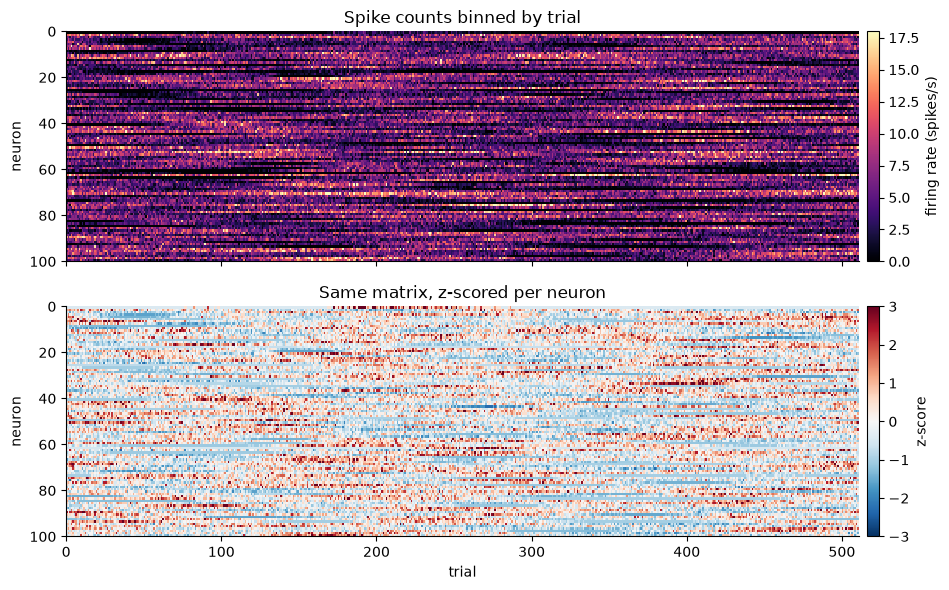

In [7]:
# sum spikes within each trial for each neuron
counts = spikes.reshape(N_NEURONS, n_trials, per_trial).sum(axis=2)   # (neurons, trials)
fr     = counts / TRIAL_DUR                                            # convert to spikes/s
frz    = (fr - fr.mean(axis=1, keepdims=True)) / fr.std(axis=1, keepdims=True)  # z-score

def show_matrix(ax, M, cmap, vmin, vmax, title, cbar_label, ylabel='neuron'):
    """Display a neurons × trials matrix. interpolation='nearest' prevents matplotlib
    from blurring across trials or neurons, which would invent structure."""
    im = ax.imshow(M, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation='nearest', extent=[0, M.shape[1], M.shape[0], 0])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label=cbar_label, fraction=0.025, pad=0.01)
    return im

fig, axes = plt.subplots(2, 1, figsize=(9.5, 6), sharex=True)
show_matrix(axes[0], fr, 'magma', 0, np.percentile(fr, 99.5),
            'Spike counts binned by trial', 'firing rate (spikes/s)')
show_matrix(axes[1], frz, 'RdBu_r', -3, 3,
            'Same matrix, z-scored per neuron', 'z-score')
axes[1].set_xlabel('trial')
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

**What to notice:** Even though neurons were generated independently, the
z-scored matrix shows bands of simultaneous high and low activity. This
is the slow fluctuation. *Can we tell the difference between real co-modulation
and this kind of coincidental shared drift?*

</div>


## 4. Same matrix, but with rows sorted by Rastermap


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

[Rastermap](https://github.com/MouseLand/rastermap) sorts the rows such that
neurons with similar activity patterns end up adjacent. On data *without* slow
fluctuations this sorts neurons by their tuning properties. On our simulated
data, it sorts them by which phase of the slow fluctuation each neuron happens
to be in.

</div>


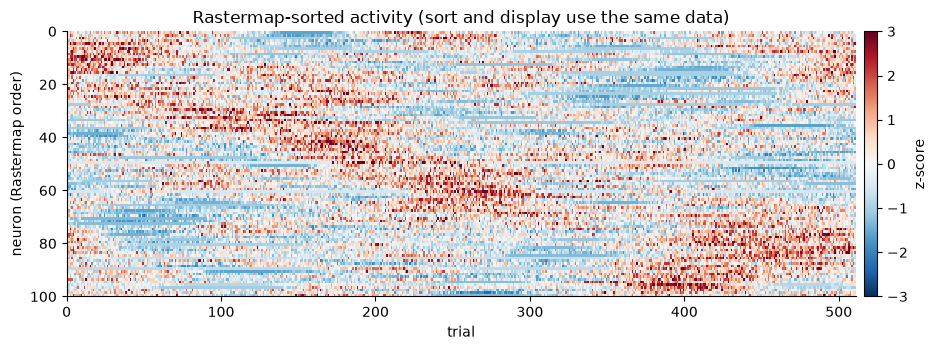

In [8]:
def rastermap_order(M):
    """Neuron ordering from Rastermap fit on matrix M (neurons x trials).
    Returns isort: an integer array of neuron indices in sorted order."""
    return Rastermap(n_clusters=10, n_PCs=32, locality=0.5, time_lag_window=0, verbose=False).fit(M).isort


# use rastermap to sort the z-scored spiking data (frz) by similarity
isort = rastermap_order(frz)

# plot the sorted matrix of neurons x trials
fig, ax = plt.subplots(figsize=(9.5, 3.6))
show_matrix(ax, frz[isort], 'RdBu_r', -3, 3,
            'Rastermap-sorted activity (sort and display use the same data)',
            'z-score', ylabel='neuron (Rastermap order)')
ax.set_xlabel('trial')
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

### Cross-validating the sort: two ways to hold out half the trials

To test whether the sorted structure is real, we should fit the sort on *some*
trials and evaluate it on *different* trials. Let's look at two different methods 
for choosing which half of the trials to use for **fitting** the sort versus **evaluating** it.


</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

#### Helper functions:
- `neighbour_corr` measures how well the sort captured shared structure: it
computes the mean Pearson correlation between adjacent neurons in the sorted order,
evaluated on a matrix `M`.

- `mean_pair_corr` measures the mean correlation across all possible neuron pairs. 
It represents the baseline you would get if you picked two neurons at random, regardless 
of where they ended up in the sort.

- `plot_split` turns our matrix plotting code for into a reusable function.

</div>

In [9]:
def neighbour_corr(order, M):
    """Mean Pearson r between neurons that `order` placed adjacent to each other,
    measured on matrix M. High on fitting data, stays high if structure is real."""
    C = np.corrcoef(M)
    return np.mean(C[order[:-1], order[1:]])

def mean_pair_corr(M):
    """Mean Pearson r over all neuron pairs (baseline for neighbour_corr)."""
    C = np.corrcoef(M)
    return np.mean(C[np.triu_indices(len(C), 1)])

def plot_split(order, fit_idx, held_idx, fit_label, held_label):
    """Plot a neurons x trials matrix for both the fitting and held-out trial sets,
    using the neuron ordering `order` derived from `fit_idx` trials only."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
    show_matrix(axes[0], frz[order][:, fit_idx],  'RdBu_r', -3, 3,
                f'Sorted on {fit_label}, showing {fit_label}',
                'z-score', ylabel=f'neuron ({fit_label} order)')
    show_matrix(axes[1], frz[order][:, held_idx], 'RdBu_r', -3, 3,
                f'Same sort order, showing held-out {held_label}',
                'z-score', ylabel=f'neuron ({fit_label} order)')
    axes[0].set_xlabel(fit_label)
    axes[1].set_xlabel(held_label)
    plt.tight_layout()
    plt.show()
    

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

### Method 1: Interleaved split (odd vs even trials)

 Train the row sorting on every other trial (odd trials), then evaluate the resulting structure on the remaining trials (even trials). 

 </div>

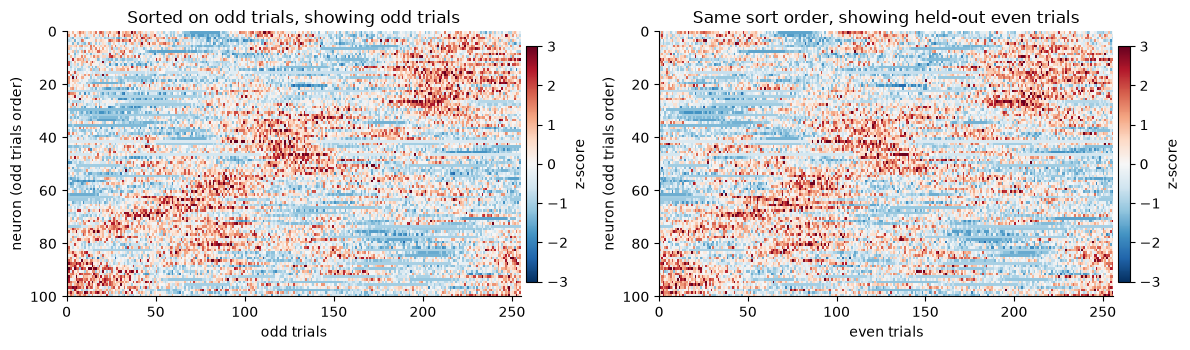

Interleaved Split:
Fit (odd trials):       neighbour_corr = +0.250
Held-out (even trials): neighbour_corr = +0.242
Baseline (all pairs):   mean_pair_corr = +0.004


In [10]:
# 1. Split the trials into interleaved sets (odd vs even):
odd, even = np.arange(1, n_trials, 2), np.arange(0, n_trials, 2)

# 2. Fit the sort using only the odd trials:
order_odd = rastermap_order(frz[:, odd])

# 3. Plot the sorted fit on both the odd and even trials independently:
plot_split(order_odd, odd, even, 'odd trials', 'even trials')

# 4. Compute the neighbour_corr on both sets of trials and the mean_pair_corr on the held-out even trials:
neighbour_odd = neighbour_corr(order_odd, frz[:, odd])
neighbour_even = neighbour_corr(order_odd, frz[:, even])
meanpair_even = mean_pair_corr(frz[:, even])

print('Interleaved Split:')
print(f'Fit (odd trials):       neighbour_corr = {neighbour_odd:+.3f}')
print(f'Held-out (even trials): neighbour_corr = {neighbour_even:+.3f}')
print(f'Baseline (all pairs):   mean_pair_corr = {meanpair_even:+.3f}')

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

Because neighbouring trials share the same slow fluctuation, the training and test trials carry a similar slow structure. A sort fit on odd trials transfers to even trials. 

Does this structure in the held-out trials *only* appear because they happen to have the same slow drift state as the training trials? Let's try a different method for holding out half of the trials to find out. 

 </div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto;">

### Exercise 2: Method 2 - Contiguous split (trials from first half of session vs second half)

 A neuron's slow fluctuation during the first half of the session will be different from its slow fluctuation in the second half of the session. Here you will train the fit on trials from the **first half** of the session, then evaluate the resulting structure on the trials from the **second half**.
 1. Split the trials into first half vs second half of the full session
 2. Fit the sort on trials from the first half of the session
 3. Plot the resulting fit on both the training and testing trials independently
 4. Compute `neighbour_corr` on the held-out trials from the second half of the session

 </div>

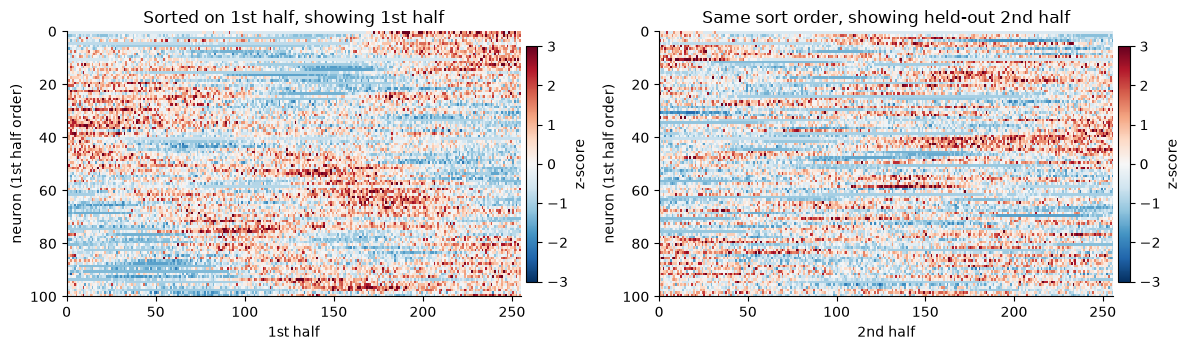

Contiguous Split:
Fit (1st half):       neighbour_corr = +0.290
Held-out (2nd half): neighbour_corr = +0.064
Baseline (all pairs):   mean_pair_corr = +0.005


In [11]:
# Your code here

# 1. Split the trials into those from the first half of the session vs the second:
# Hint: use np.arange(start, stop)
first = np.arange(0, n_trials // 2)
second = np.arange(n_trials // 2, n_trials)

# 2. Fit the sort using only the first half of trials:
order_first = rastermap_order(frz[:, first])

# 3. Plot the sorted fit on both the first and second half of trials independently:
plot_split(order_first, first, second, '1st half', '2nd half')

# 4. Compute the neighbour_corr on both sets of trials and the mean_pair_corr on the held-out second half of trials:
neighbour_first = neighbour_corr(order_first, frz[:, first])
neighbour_second = neighbour_corr(order_first, frz[:, second])
meanpair_second = mean_pair_corr(frz[:, second])

print('Contiguous Split:')
print(f'Fit (1st half):       neighbour_corr = {neighbour_first:+.3f}')
print(f'Held-out (2nd half): neighbour_corr = {neighbour_second:+.3f}')
print(f'Baseline (all pairs):   mean_pair_corr = {meanpair_second:+.3f}')

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

### What does this mean?

The slow fluctuation of each neuron during the first half of trials is not the same as during the second half. Interleaving the trials in method 1 was **not** a test of the sort. Neighbouring trials share the same slow fluctuation, so the held-out half carries the same chance correlations the sort was fit to, and the structure replicates. Splitting the session into contiguous halves **is** a test, and the similarity ordering does not transfer.

</div>

## 5. Test 1 — Correlation with Pupil Diameter


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

Our original question asked whether any of these neurons are modulated by the animal's
arousal state, which is often tracked via **pupil diameter**. The standard analysis:
compute the Pearson correlation between each neuron's firing rate and the pupil,
then ask how many are significant (p < 0.05).

We have a simulated pupil trace `pupil` that fluctuates on a ~20 s timescale.


**In our simulated data, the neurons were generated independently of the pupil.** Therefore, 
we should expect our analysis to find that 0 neurons are significantly correlated with the pupil diameter 
(or ~5% by chance if we use p < 0.05).

Let us see what the standard analysis reports.

</div>


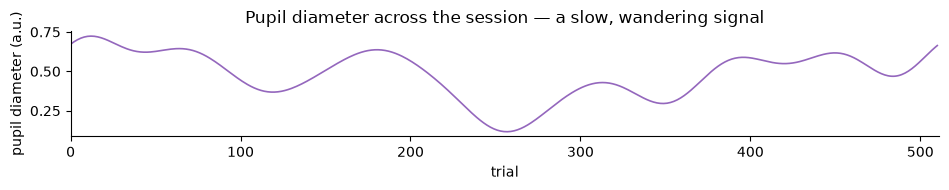

In [12]:
# Plot the pupil trace
fig, ax = plt.subplots(figsize=(9.5, 2))
ax.plot(pupil, color='tab:purple', lw=1.2)
ax.set_xlim(0, n_trials)
ax.set_xlabel('trial')
ax.set_ylabel('pupil diameter (a.u.)')
ax.set_title('Pupil diameter across the session — a slow, wandering signal')
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

### Calculate the correlation with pupil diameter

First, we will z-score the pupil trace so that it is on the same scale as the z-scored firing rates. 

Then we will compute the Pearson correlation between each neuron's firing rate and the pupil trace, along with the standard parametric p=value.  This is the analysis we want to evaluate; if our neurons truly have **no relationship** with the pupil, we would expect roughly **5%** of them to be flagged as significant by chance.

We will compute `r_crit`, the minimum correlation coefficient needed to reach statistical significance given our sample size. Any neuron whose absolute
correlation exceeds `r_crit` will be called significant at p < 0.05.

</div>

In [13]:
pupil_z = (pupil - pupil.mean()) / pupil.std()   # z-scored version for later use

# Compute Pearson correlation + p-value for every neuron
res     = [stats.pearsonr(row, pupil) for row in fr]
r_pupil = np.array([x.statistic for x in res])
p_pupil = np.array([x.pvalue    for x in res])
n_sig   = np.sum(p_pupil < 0.05)

def crit_r(n):
    """Critical |r| for p < 0.05 (two-sided t-test, n-2 df): solved for r."""
    t = stats.t.ppf(1 - 0.05 / 2, n - 2)
    return t / np.sqrt(t ** 2 + n - 2)

r_crit = crit_r(n_trials)
print(f'n = {n_trials} trials  →  any |r| > {r_crit:.3f} gives p < 0.05')

# Bin edges with r_crit exactly on edges (so no bar mixes significant/non-significant)
_edges = np.arange(0, 0.8 + r_crit, r_crit)
R_BINS = np.concatenate([-_edges[1:][::-1], _edges])


n = 511 trials  →  any |r| > 0.087 gives p < 0.05


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

### Visualize the correlation

We can now visualize the full distribution of correlations across all 100 neurons. Bars in red exceed the significance threshold. 

For a true null, the p-value histogram on the right would be flat.

</div>

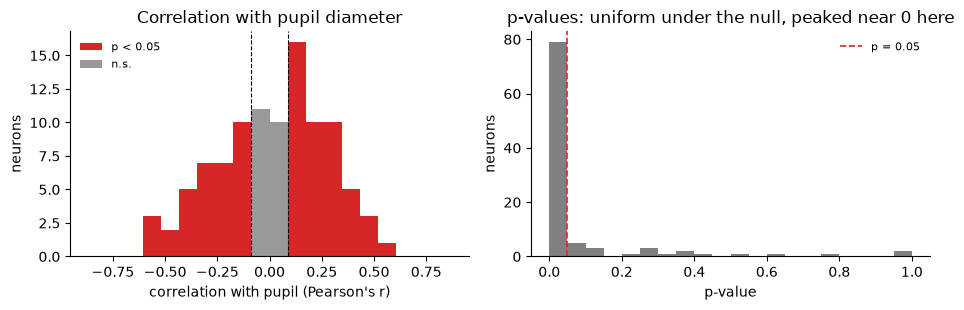

In [14]:
def hist_by_significance(ax, r, title):
    """Histogram of correlations coloured by significance."""
    _, _, patches = ax.hist(r, bins=R_BINS)
    for patch, lo, hi in zip(patches, R_BINS[:-1], R_BINS[1:]):
        patch.set_facecolor('tab:red' if abs(lo + hi) / 2 > r_crit else '0.6')
    for side in (-1, 1):
        ax.axvline(side * r_crit, color='k', ls='--', lw=0.8)
    ax.set_xlabel("correlation with pupil (Pearson's r)")
    ax.set_ylabel('neurons')
    ax.set_title(title)
    ax.legend(handles=[Patch(facecolor='tab:red', label='p < 0.05'),
                       Patch(facecolor='0.6', label='n.s.')],
              frameon=False, fontsize=8, loc='upper left')

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
hist_by_significance(axes[0], r_pupil, 'Correlation with pupil diameter')
axes[1].hist(p_pupil, bins=np.linspace(0, 1, 21), color='0.5')
axes[1].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
axes[1].set_xlabel('p-value')
axes[1].set_ylabel('neurons')
axes[1].set_title('p-values: uniform under the null, peaked near 0 here')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()




<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto;">

### Exercise 3: How many false positives?

1. Print `n_sig`, the number of neurons flagged as significantly correlated with. 

2. According to our null, we expected ~5% of neurons to be flagged by chance. 
   How many neurons would you expect to have flagged by chance? Is this number larger or smaller than the number we actually saw flagged?

3. What is the typical correlation strength across the population? 

4. What is the value of the correlation coefficient for the neuron that is most strongly correlated with the pupil?


</div>


In [15]:
# Your code here

# 1. Print the number of neurons flagged as significantly correlated with pupil size
# Hint: use n_sig
print(f'1. Number of neurons significantly correlated with pupil: {n_sig}')


# 2. Under the null hypothesis, how many neurons would we expect to see flagged given 5% flagged by chance?
# Hint: use N_NEURONS
n_chance = 0.05 * N_NEURONS
print(f'2. Number of neurons expected by chance: {n_chance}')

# 3. What is the typical correlation strength across the population? 
# Hint: Compute the median of the absolute correlation coefficients (using np.median and r_pupil)
med_corr = np.median(np.abs(r_pupil))
print(f'3. Median |r| = {med_corr:.3f}')


#4. What is the value of the correlation coefficient for the neuron that is most strongly correlated with the pupil?
# Hint: Compute the maximum of the absolute correlation coefficients (using np.max and r_pupil)
max_corr = np.max(np.abs(r_pupil))
print(f'4. Largest |r| = {max_corr:.3f}')


1. Number of neurons significantly correlated with pupil: 79
2. Number of neurons expected by chance: 5.0
3. Median |r| = 0.181
4. Largest |r| = 0.571


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

#### What does this finding mean?
Over three quarters of our neurons appear significantly correlated with the pupil — far above the 5 we would expect by chance. 

If this were real data, this would look like a striking finding. But since we simulated this data, we **know** that these neurons were generated with absolutely no relationship to the pupil, which means something is wrong with the analysis. In the next sections we will work out exactly what went wrong.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

### Further visualization of the result: plot neurons sorted by correlation coefficient

To get a clearer picture of what these correlations look like, we can sort neurons by their **correlation coefficient** and display the activity matrix alongside the pupil trace. 

Neurons at the top of the matrix are most *positively* correlated with the pupil, and those at the bottom are most *negatively* correlated. If the correlations were real, you would expect to see the neural activity track the pupil trace across the session.

</div>

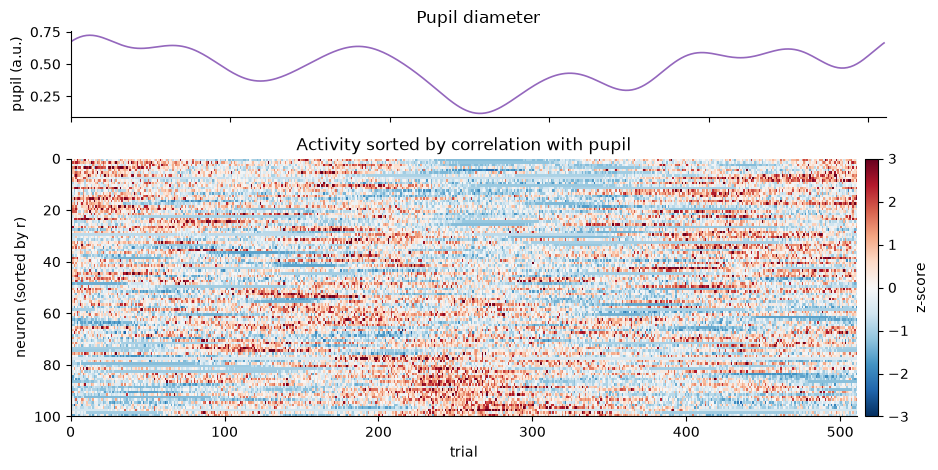

In [16]:
# Sort neurons by correlation and display the activity matrix alongside the pupil
order_pupil = np.argsort(r_pupil)[::-1]

fig, axes = plt.subplots(2, 1, figsize=(9.5, 4.8), sharex=True,
                         gridspec_kw=dict(height_ratios=[1, 3]))
axes[0].plot(pupil, color='tab:purple', lw=1.2)
axes[0].set_ylabel('pupil (a.u.)')
axes[0].set_title('Pupil diameter')
show_matrix(axes[1], frz[order_pupil], 'RdBu_r', -3, 3,
            'Activity sorted by correlation with pupil',
            'z-score', ylabel='neuron (sorted by r)')
axes[1].set_xlabel('trial')
axes[1].set_xlim(0, n_trials)
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

### Interactive plot: Click a row to overlay that neuron on the pupil trace

The next cell switches to interactive mode so you can click any row of the matrix
to overlay that neuron's firing rate on the pupil trace. When you are finish exploring this interactive widget, 
run the `%matplotlib inline` cell to return to static plots.

</div>


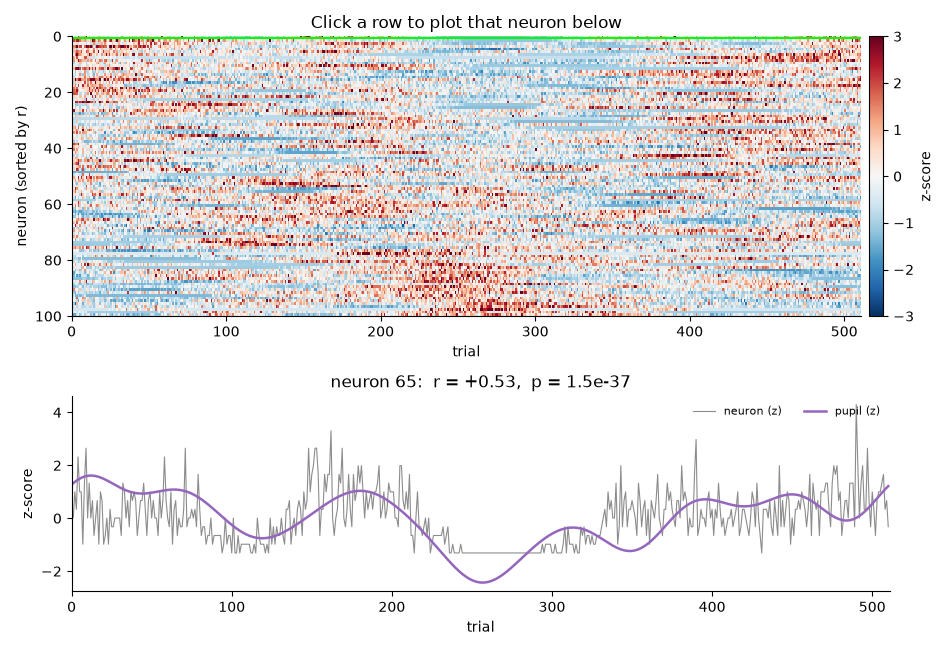

In [17]:
%matplotlib widget

M_sorted = frz[order_pupil]

fig, (ax_im, ax_tr) = plt.subplots(2, 1, figsize=(9.5, 6.5),
                                   gridspec_kw=dict(height_ratios=[2, 1.4]))
fig.canvas.header_visible = False
show_matrix(ax_im, M_sorted, 'RdBu_r', -3, 3,
            'Click a row to plot that neuron below', 'z-score',
            ylabel='neuron (sorted by r)')
ax_im.set_xlabel('trial')
row_marker = ax_im.axhline(0.5, color='lime', lw=1.5)

line_neuron, = ax_tr.plot(M_sorted[0], color='0.55', lw=0.8, label='neuron (z)')
ax_tr.plot(pupil_z, color='tab:purple', lw=1.8, label='pupil (z)')
ax_tr.set_xlim(0, n_trials)
ax_tr.set_xlabel('trial')
ax_tr.set_ylabel('z-score')
ax_tr.legend(frameon=False, fontsize=8, ncol=2, loc='upper right')

def show_row(row):
    i = order_pupil[row]
    line_neuron.set_ydata(frz[i])
    row_marker.set_ydata([row + 0.5, row + 0.5])
    ax_tr.set_title(f'neuron {i}:  r = {r_pupil[i]:+.2f},  p = {p_pupil[i]:.1e}')
    ax_tr.relim()
    ax_tr.autoscale_view(scalex=False)
    fig.canvas.draw_idle()

def on_click(event):
    if event.inaxes is ax_im and event.ydata is not None:
        show_row(int(np.clip(event.ydata, 0, N_NEURONS - 1)))

fig.canvas.mpl_connect('button_press_event', on_click)
show_row(0)
plt.tight_layout()


In [18]:
plt.close('all')
%matplotlib inline


## 6. A control that fails: randomly shuffle each neuron's timecourse


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

A common sanity check is to **randomly permute** the trial order of each neuron
and recompute the correlations. The idea is: if the correlation is real, it
should survive shuffling; if it is a statistical artefact, shuffling should
destroy it.

</div>


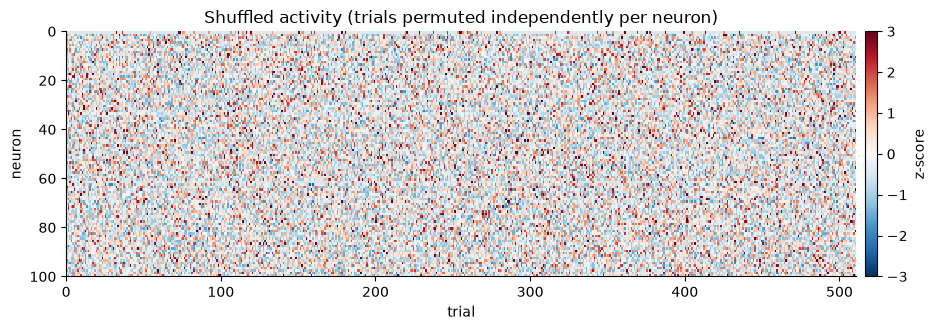

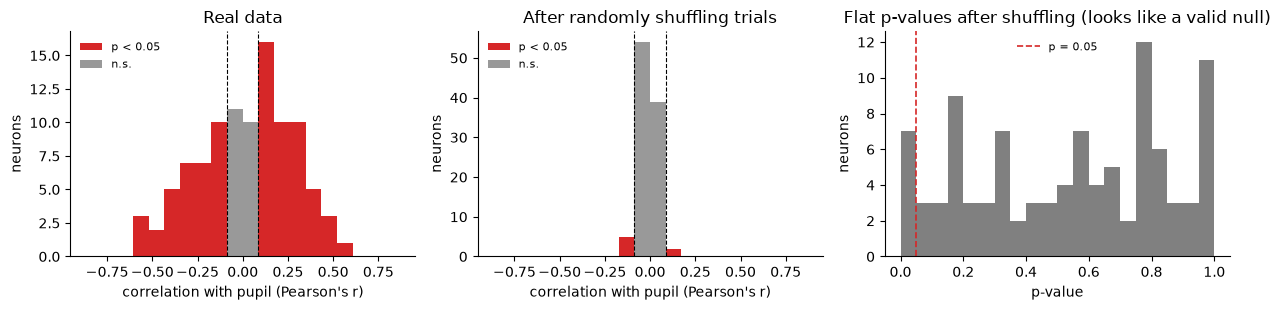

Real data:          79 / 100 neurons significant (p < 0.05)
After shuffling:     7 / 100 neurons significant (p < 0.05)

The shuffle comes out at chance, making the real result LOOK validated.
But the shuffle destroyed the slow structure — not a fair test.


In [19]:
# Independently permute the trial order of each neuron
# This keeps each neuron's firing-rate distribution but destroys its temporal structure
fr_shuffled  = np.array([rng.permutation(row) for row in fr])
frz_shuffled = ((fr_shuffled - fr_shuffled.mean(axis=1, keepdims=True))
                / fr_shuffled.std(axis=1, keepdims=True))

res_sh        = [stats.pearsonr(row, pupil) for row in fr_shuffled]
r_shuffled    = np.array([x.statistic for x in res_sh])
p_shuffled    = np.array([x.pvalue    for x in res_sh])
n_sig_shuffled = np.sum(p_shuffled < 0.05)

# Plot the shuffled activity matrix
fig, ax = plt.subplots(figsize=(9.5, 3.4))
show_matrix(ax, frz_shuffled, 'RdBu_r', -3, 3,
            'Shuffled activity (trials permuted independently per neuron)', 'z-score')
ax.set_xlabel('trial')
plt.tight_layout(); plt.show()


# Plot the correlation histograms
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.2))
hist_by_significance(axes[0], r_pupil,    'Real data')
hist_by_significance(axes[1], r_shuffled, 'After randomly shuffling trials')
axes[2].hist(p_shuffled, bins=np.linspace(0, 1, 21), color='0.5')
axes[2].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
axes[2].set_xlabel('p-value')
axes[2].set_ylabel('neurons')
axes[2].set_title('Flat p-values after shuffling (looks like a valid null)')
axes[2].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print(f'Real data:         {n_sig:3d} / {N_NEURONS} neurons significant (p < 0.05)')
print(f'After shuffling:   {n_sig_shuffled:3d} / {N_NEURONS} neurons significant (p < 0.05)')
print()
print('The shuffle comes out at chance, making the real result LOOK validated.')
print('But the shuffle destroyed the slow structure — not a fair test.')


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto;">

### Exercise 4: Why does the shuffle fail?

After shuffling, only ~5 neurons are significant (as expected by chance).
This makes the original 79/100 look like a *real* effect — validated by the null.

1. Look at the shuffled activity matrix below. What happened to the slow structure?
2. The pupil trace still has its slow fluctuations. The shuffled neural data does not.
   What kind of correlations is the t-test actually sensitive to?
3. What property must a valid null distribution **preserve** about the data?

</div>


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto;">

**Why this fails:** the shuffled distribution does come out at chance (~5%
significant), which makes the original result look validated. But the shuffle
*destroyed the slow temporal structure* that generated the spurious correlation
in the first place — it never tested whether the original alignment was real.

A valid null has to **preserve** the slow fluctuation structure while **breaking**
only the alignment with the variable of interest. The random shuffle does neither.

</div>

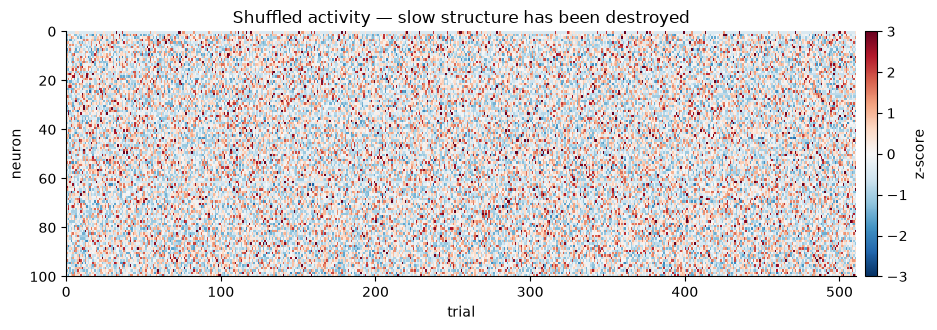

In [20]:
fig, ax = plt.subplots(figsize=(9.5, 3.4))
show_matrix(ax, frz_shuffled, 'RdBu_r', -3, 3,
            'Shuffled activity — slow structure has been destroyed', 'z-score')
ax.set_xlabel('trial')
plt.tight_layout()
plt.show()


## 7. Two Controls That Work


### 7a. Circular Shift


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

A **circular shift** slides a neuron's entire timecourse forward or backward by
some number of trials, wrapping the end around to the beginning. Crucially:

- ✅ **Preserved:** the slow fluctuation structure of each neuron (same autocorrelation)
- ✅ **Preserved:** the slow structure of the pupil (unchanged)
- ❌ **Broken:** the temporal alignment between neuron and pupil

Because we used `mode='wrap'` when generating the slow traces, every shift is a
valid sample from the same generative process — there is nothing special about
a shift of 0. So the set of correlations across many shift amounts is a valid
null distribution for the correlation at shift 0 (the real data).

The resulting per-neuron p-value is: *how often does a circularly-shifted version
of the neuron reach a correlation with the pupil as large as the real one?*

#### Fast vectorised correlation helper

Computing correlations for 200 shifts × 100 neurons iteratively using
`scipy.stats.pearsonr` takes ~15 s. Instead, we express Pearson r as a
dot product of z-scored variables — equivalent, but ~150× faster.

</div>


In [ ]:
def corr_rows(M, v):
    """Pearson correlation between every row of M and vector v.
    Written as a dot product of z-scored arrays (equivalent to scipy.stats.pearsonr).
    Processes 100 neurons and 200 shift amounts in <0.1 s."""
    Mz = (M - M.mean(axis=1, keepdims=True)) / M.std(axis=1, keepdims=True)
    vz = (v - v.mean()) / v.std()
    return (Mz @ vz) / v.size

# Verify it matches scipy
print('corr_rows matches scipy.stats.pearsonr:',
      np.allclose(corr_rows(fr, pupil), r_pupil))


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #DFF0D8; ">

### ✏️ Checkpoint: Implement a single circular shift

Before we run 200 shifts, try one yourself.

1. Shift `fr` by exactly 50 trials using `np.roll(fr, 50, axis=1)`.
2. Compute its correlation with the pupil using `corr_rows`.
3. Compare the distribution of per-neuron correlations to `r_pupil`.
   Are they similar or different? Why?
4. Does a single shift tell you definitively whether the real correlations are real?

**Hint:** `corr_rows(np.roll(fr, 50, axis=1), pupil)`

</div>


In [ ]:
# ✏️ Your code here
# Hint: r_shift50 = corr_rows(np.roll(fr, 50, axis=1), pupil)
print('shift-50 correlations:', r_shift50[:5].round(3))
print('real correlations:    ', r_pupil[:5].round(3))



In [ ]:
N_SHIFT      = 200
shift_amounts = rng.integers(1, n_trials, N_SHIFT)

# Compute correlation between circularly-shifted fr and the pupil for each shift amount
r_circ = np.array([corr_rows(np.roll(fr, s, axis=1), pupil) for s in shift_amounts])
# r_circ shape: (N_SHIFT, N_NEURONS)

# Per-neuron p-value: fraction of shifts with |r_null| >= |r_real|
p_circ     = (np.sum(np.abs(r_circ) >= np.abs(r_pupil), axis=0) + 1) / (N_SHIFT + 1)
n_sig_circ = np.sum(p_circ < 0.05)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
axes[0].hist(r_circ.ravel(), bins=R_BINS, density=True, color='0.6',
             label='circular shifts (null)')
axes[0].hist(r_pupil, bins=R_BINS, density=True, color='tab:blue', alpha=0.6,
             label='real')
axes[0].set_xlabel("correlation with pupil (Pearson's r)")
axes[0].set_ylabel('density')
axes[0].set_title('Circular-shift null covers the real correlations')
axes[0].legend(frameon=False, fontsize=8)
axes[1].hist(p_circ, bins=np.linspace(0, 1, 21), color='0.6')
axes[1].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
axes[1].set_xlabel('p-value vs circular-shift null')
axes[1].set_ylabel('neurons')
axes[1].set_title('p-values — uniform under the null')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print(f'Parametric (t-test) p < 0.05:    {n_sig:3d} / {N_NEURONS} neurons')
print(f'Vs circular-shift null p < 0.05: {n_sig_circ:3d} / {N_NEURONS} neurons')


### 7b. Correlate with a Different Session's Pupil Trace


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

A conceptually equivalent control: instead of shifting the neural data, use the
pupil trace from a completely different recording session. That pupil trace has
the same slow fluctuation structure (same animal, same timescale) but no
relationship to these specific neurons.

This is called a **session-permutation null**. It is especially useful when you
do not have periodic data (so circular shifts are not well-defined), or when you
want to explicitly compare recordings across sessions.

</div>


In [ ]:
N_SESSIONS = 200
# Draw pupil traces from other 'sessions': same generative process, same timescale,
# but completely unrelated to these neurons
other_pupil = 0.5 + 0.15 * slow_traces(rng, N_SESSIONS, n_trials, PUPIL_TAU / TRIAL_DUR)

r_other     = np.array([corr_rows(fr, p) for p in other_pupil])
p_other     = (np.sum(np.abs(r_other) >= np.abs(r_pupil), axis=0) + 1) / (N_SESSIONS + 1)
n_sig_other = np.sum(p_other < 0.05)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
axes[0].hist(r_other.ravel(), bins=R_BINS, density=True, color='0.6',
             label="other sessions' pupil (null)")
axes[0].hist(r_pupil, bins=R_BINS, density=True, color='tab:blue', alpha=0.6,
             label='this session')
axes[0].set_xlabel("correlation with pupil (Pearson's r)")
axes[0].set_ylabel('density')
axes[0].set_title('Session-permutation null covers the real correlations')
axes[0].legend(frameon=False, fontsize=8)
axes[1].hist(p_other, bins=np.linspace(0, 1, 21), color='0.6')
axes[1].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
axes[1].set_xlabel('p-value vs session-permutation null')
axes[1].set_ylabel('neurons')
axes[1].set_title('p-values — also uniform')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print(f'Parametric p < 0.05:               {n_sig:3d} / {N_NEURONS} neurons')
print(f'Vs session-permutation null p<0.05: {n_sig_other:3d} / {N_NEURONS} neurons')


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #DFF0D8; ">

### ✏️ Checkpoint: Comparing the three approaches

You now have three significance thresholds for the same data:

| Method | # significant |
|--------|--------------|
| Parametric (t-test on r) | `n_sig` |
| Circular-shift null | `n_sig_circ` |
| Session-permutation null | `n_sig_other` |

1. Fill in the table by printing each variable. Which methods agree?
2. Both the circular-shift and session-permutation nulls find ~5% significant.
   The parametric test finds far more. What is the parametric test
   getting wrong?
3. Would you use the circular-shift or session-permutation method if you only had
   data from one session? Which can you always use?

</div>


In [ ]:
# ✏️ Your code here
# Hint: print(n_sig, n_sig_circ, n_sig_other)



## 8. How Many Independent Samples Do You Actually Have?


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

The root cause of the false positives is that **autocorrelated data has fewer
independent observations than the raw sample size suggests**.

**Bartlett's formula** relates the effective number of independent samples
*n*_eff to the autocorrelations of the two signals:

$$
n_{\text{eff}} = \frac{n}{1 + 2 \sum_{k=1}^{\lfloor n/4 \rfloor}
    \left(1 - \frac{k}{n}\right) \rho_x(k)\, \rho_y(k)}
$$

where ρ_x(k) and ρ_y(k) are the autocorrelations of the two signals at lag k.
When neither signal is autocorrelated, every lag term is 0 and n_eff = n.
When both wander on a timescale of many trials, the sum is large and n_eff ≪ n.

The honest significance threshold should use *n*_eff, not *n*. This is
equivalent to using the circular-shift null — both give the same answer.

</div>


In [ ]:
def autocorr(x, max_lag):
    """Autocorrelation of x at lags 0..max_lag, normalised to 1 at lag 0."""
    x = x - x.mean()
    full = np.correlate(x, x, 'full')[len(x) - 1:]
    return (full / full[0])[:max_lag + 1]

def effective_n(x, y):
    """Bartlett's effective sample size for two autocorrelated series.
    Returns the equivalent number of independent paired samples."""
    n = len(x)
    max_lag = n // 4
    k = np.arange(1, max_lag + 1)
    return n / (1 + 2 * np.sum((1 - k / n) * autocorr(x, max_lag)[1:]
                               * autocorr(y, max_lag)[1:]))

MAX_LAG   = 100
ac_neuron = np.mean([autocorr(row, MAX_LAG) for row in fr], axis=0)
ac_pupil  = autocorr(pupil, MAX_LAG)
n_eff     = np.median([effective_n(row, pupil) for row in fr])
# Cross-check: the circular-shift null measures the same thing via 1/Var(r)
n_eff_null = 1 / r_circ.var()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.1))
axes[0].plot(ac_neuron, color='k', label='neurons (mean)')
axes[0].plot(ac_pupil, color='tab:purple', label='pupil')
axes[0].plot(ac_neuron * ac_pupil, color='tab:orange', label='product (inflates r)')
axes[0].axhline(0, color='0.7', lw=0.8)
axes[0].set_xlabel('lag (trials)')
axes[0].set_ylabel('autocorrelation')
axes[0].set_title('Both signals are autocorrelated for tens of trials')
axes[0].legend(frameon=False, fontsize=8)

grid = np.linspace(-0.8, 0.8, 400)
axes[1].hist(r_circ.ravel(), bins=R_BINS, density=True, color='0.75',
             label='circular-shift null')
axes[1].plot(grid, stats.norm.pdf(grid, 0, 1 / np.sqrt(n_eff)), color='tab:orange',
             lw=2, label=f'predicted: sd = 1/√{n_eff:.0f}')
for side in (-1, 1):
    axes[1].axvline(side * r_crit,          color='k',       ls='--', lw=0.9,
                    label='threshold from n = 511' if side == 1 else None)
    axes[1].axvline(side * crit_r(n_eff), color='tab:red', ls='--', lw=1.2,
                    label=f'threshold from n_eff = {n_eff:.0f}' if side == 1 else None)
axes[1].set_xlabel("correlation with pupil (Pearson's r)")
axes[1].set_ylabel('density')
axes[1].set_title('Null width follows from the effective n')
axes[1].legend(frameon=False, fontsize=8, loc='upper center',
               bbox_to_anchor=(0.5, -0.28), ncol=2)
plt.tight_layout()
plt.show()

print(f'From autocorrelations:  n_eff = {n_eff:.0f}   (median over neurons)')
print(f'From circular-shift null: 1/Var(r) = {n_eff_null:.0f}')
print()
print(f'Nominal   n = {n_trials:5d}  →  threshold |r| = {r_crit:.3f}  →  '
      f'{np.sum(np.abs(r_pupil) > r_crit):3d} / {N_NEURONS} "significant"')
print(f'Effective n = {n_eff:5.0f}  →  threshold |r| = {crit_r(n_eff):.3f}  →  '
      f'{np.sum(np.abs(r_pupil) > crit_r(n_eff)):3d} / {N_NEURONS} significant')


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #DFF0D8; ">

### ✏️ Checkpoint: Understanding effective N

1. Compute `effective_n(fr[0], pupil)` — the effective N for a single neuron.
   How does it compare to `n_trials` = 511?
2. The circular-shift null standard deviation equals `1/√n_eff`.
   Does the predicted curve (orange) fit the circular-shift null histogram?
3. How many neurons are significant using the corrected threshold (`crit_r(n_eff)`)
   vs the naive threshold (`r_crit`)? Print both counts.
4. The two estimates of n_eff (from autocorrelations and from 1/Var of the null)
   should agree. Do they?

**Hint:** `effective_n(fr[0], pupil)`

</div>


In [ ]:
# ✏️ Your code here
# Hint: neff_neuron0 = effective_n(fr[0], pupil)
print(f'n_eff for neuron 0: {neff_neuron0:.1f}  (nominal n = {n_trials})')
print(f'Naive threshold gives:    {np.sum(np.abs(r_pupil) > r_crit)} / {N_NEURONS} significant')
print(f'Corrected threshold gives: {np.sum(np.abs(r_pupil) > crit_r(n_eff))} / {N_NEURONS} significant')



## 9. Test 2 — Decoding the Block Variable


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

The second common analysis: train a linear decoder to read out the task block
variable (+1 or −1) from the neural population, then evaluate it with
**k-fold cross-validation**. The idea is that a good decoder generalises to
held-out data it was never trained on.

We use **Linear Discriminant Analysis (LDA)**, a simple linear classifier.
Ordinary k-fold cross-validation shuffles all trials and splits them into
folds — so each fold's test set includes trials scattered throughout the session.

**The same slow-fluctuation problem applies here.** A trial's neighbours share
its slow fluctuation state. If a trial is in the test fold but its neighbours
are in training, the decoder can use the shared slow state to predict the test
trial — not because it learned the block variable, but because it learned the
current drift state. The neurons were generated with *no* block signal.

</div>


In [ ]:
# Plot the block variable
fig, ax = plt.subplots(figsize=(9.5, 1.8))
ax.plot(block_values, '.-', ms=3, lw=0.8, color='k')
ax.set_xlim(0, n_trials)
ax.set_yticks([-1, 1])
ax.set_xlabel('trial')
ax.set_ylabel('block value')
ax.set_title(f'The block variable ({N_BLOCKS} blocks, {BLOCK_LEN[0]}–{BLOCK_LEN[1]} trials each)')
plt.tight_layout()
plt.show()


In [ ]:
X = fr.T          # sklearn convention: (samples, features) = (trials, neurons)
y = block_values

def trialwise_cv(X, y, folds=10, seed=0):
    """Ordinary k-fold cross-validation: trials are shuffled and split randomly.
    Trials from the same block can appear in both training and test sets."""
    kf = KFold(folds, shuffle=True, random_state=seed)
    return np.mean([LinearDiscriminantAnalysis().fit(X[tr], y[tr]).score(X[te], y[te])
                    for tr, te in kf.split(X)])

acc = trialwise_cv(X, y)
print(f'Trial-wise cross-validated accuracy: {acc*100:.1f}%   (chance = 50%)')


In [ ]:
def plot_fold(ax, X, y, train, test, title):
    """Train on `train` indices, plot the continuous decoder output for all trials."""
    model = LinearDiscriminantAnalysis().fit(X[train], y[train])
    out   = model.decision_function(X)
    ok    = np.sign(out[test]) == y[test]
    for b in np.unique(block_ids):
        idx = np.where(block_ids == b)[0]
        if block_values[idx[0]] > 0:
            ax.axvspan(idx[0], idx[-1] + 1, color='0.9', lw=0, zorder=0)
    ax.plot(train, out[train], '.', color='k', ms=2.5,
            label=f'training trials ({len(train)/len(y)*100:.0f}%)')
    ax.plot(test[ok],  out[test][ok],  'o', color='tab:green', ms=5, label='held-out, correct')
    ax.plot(test[~ok], out[test][~ok], 'o', color='tab:red',   ms=5, label='held-out, wrong')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xlim(0, n_trials)
    ax.set_xlabel('trial')
    ax.set_ylabel('decoder output')
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=8, ncol=3, loc='upper center',
              bbox_to_anchor=(0.5, -0.22))
    return np.mean(ok)

train, test = next(iter(KFold(10, shuffle=True, random_state=0).split(X)))
fig, ax = plt.subplots(figsize=(9.5, 3.8))
fold_acc = plot_fold(ax, X, y, train, test,
                     'One fold of trial-wise CV (shaded = +1 blocks)')
ax.set_title(f'One fold: {fold_acc*100:.0f}% of held-out trials correct')
plt.tight_layout()
plt.show()



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #DFF0D8; ">

### ✏️ Checkpoint: High accuracy, but is it real?

The trial-wise CV shows ~80% decoding accuracy. Before reading on, think:

1. Can you identify any held-out test trials (green/red dots) that land in a
   region where *neighbouring training trials* have the same block sign?
   Why would this inflate accuracy?
2. The decoder never saw the test trials — but it did train on nearby trials
   from the *same block*. What's wrong with this as a test?
3. What would you need to change about the cross-validation to avoid this problem?

</div>


## 10. The Same Failing Control: Shuffle Each Neuron's Timecourse


In [ ]:
N_SHUFFLE     = 20
acc_shuffled  = np.array([
    trialwise_cv(np.array([rng.permutation(row) for row in fr]).T, y)
    for _ in range(N_SHUFFLE)])

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.hist(acc_shuffled * 100, bins=12, color='0.6',
        label=f'shuffled ({N_SHUFFLE} draws)')
ax.axvline(acc * 100, color='tab:red', lw=2, label=f'real = {acc*100:.1f}%')
ax.axvline(50, color='0.3', ls='--', lw=1, label='chance')
ax.set_xlabel('trial-wise CV accuracy (%)')
ax.set_ylabel('count')
ax.set_title('Shuffling trials collapses decoding to chance')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print(f'Real:     {acc*100:.1f}%')
print(f'Shuffled: {acc_shuffled.mean()*100:.1f}% ± {acc_shuffled.std()*100:.1f}%')
print()
print('The shuffled null suggests the real result is not chance — but this null')
print('destroyed the slow structure that enabled the decoding in the first place.')


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

**Same reasoning as before.** The shuffle destroys the slow temporal structure,
so the null sits at chance. The real result looks validated — but it is not.
A valid null must preserve the slow fluctuation and only break its alignment with
the block variable.

</div>


## 11. Two Controls That Work


### 11a. Pseudosessions


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

A **pseudosession** is a block sequence drawn from the same generative process
as the real one (same number of blocks, same length distribution), but it is
*not* the actual sequence this session had. We then run the same trial-wise
cross-validation on the neural data but predict this fake block sequence.

If the real block sequence decodes no better than a random one, the high
accuracy is an artefact of the slow fluctuation — not of genuine block coding.

The pseudosession test is sensitive to real effects because it **preserves the
neural autocorrelation structure** (the same slow-fluctuation problem applies
equally to the real and fake block sequences). It asks: *does knowing the actual
block sequence help beyond what any slow variable would give?*

</div>


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #DFF0D8; ">

### ✏️ Checkpoint: What is a pseudosession testing?

Before running the code, make sure you understand what a pseudosession is:

1. In one sentence: what is the null hypothesis that the pseudosession test
   is evaluating?
2. If the real block decoding accuracy falls *within* the pseudosession null
   distribution, what does that mean?
3. If the real accuracy falls *above* the pseudosession null, what does that mean?
4. Why can't we just use the trial-shuffle null for this? (Think about slow drift.)

</div>


In [ ]:
N_PSEUDO = 100
acc_pseudo = np.array([
    trialwise_cv(X, make_blocks(rng, n_trials=n_trials)[0], folds=5)
    for _ in range(N_PSEUDO)])
acc_real5  = trialwise_cv(X, y, folds=5)
p_pseudo   = (np.sum(acc_pseudo >= acc_real5) + 1) / (N_PSEUDO + 1)

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.hist(acc_pseudo * 100, bins=15, color='0.6', label=f'pseudosessions (n = {N_PSEUDO})')
ax.axvline(acc_real5 * 100, color='tab:red', lw=2, label=f'real = {acc_real5*100:.1f}%')
ax.axvline(50, color='0.3', ls='--', lw=1, label='chance')
ax.set_xlabel('trial-wise CV accuracy (%)')
ax.set_ylabel('count')
ax.set_title(f'Real block decodes no better than a made-up one (p = {p_pseudo:.2f})')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print(f'Pseudosession null: {acc_pseudo.mean()*100:.1f}% ± {acc_pseudo.std()*100:.1f}%')
print(f'Real accuracy:      {acc_real5*100:.1f}%    p = {p_pseudo:.2f}')


### 11b. Leave-One-Block-Out Cross-Validation


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

**Leave-one-block-out (LOBO)** is a direct fix to the cross-validation design.
Instead of splitting trials randomly, we hold out *every trial from one block*
at a time. The training set never contains any trial from the held-out block —
so it cannot use the slow fluctuation state of that block to help decode it.

If the population truly encodes the block variable (e.g., via context-modulated
firing), a decoder trained on all other blocks should still predict the held-out
block. If the apparent decoding was due to slow drift, performance collapses —
and often goes *below* chance, because adjacent blocks have the *opposite* block
value and the decoder has learned to associate the current drift state with those
neighbouring blocks' labels.

</div>


In [ ]:
def blockout_cv(X, y, ids):
    """Leave-one-block-out CV: hold out all trials from one block at a time.
    No trial from the held-out block is ever in training. Returns one accuracy
    per block."""
    return np.array([
        LinearDiscriminantAnalysis()
        .fit(X[ids != b], y[ids != b])
        .score(X[ids == b], y[ids == b])
        for b in np.unique(ids)
    ])

blocks        = np.unique(block_ids)
acc_blockout  = blockout_cv(X, y, block_ids)

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar(blocks, acc_blockout * 100,
       color=['tab:red' if block_values[block_ids == b][0] > 0 else 'tab:blue'
              for b in blocks])
ax.axhline(np.mean(acc_blockout) * 100, color='k',
           label=f'mean = {np.mean(acc_blockout)*100:.0f}%')
ax.axhline(50, color='0.3', ls='--', lw=1, label='chance')
ax.set_xticks(blocks)
ax.set_ylim(0, 100)
ax.set_xlabel('held-out block')
ax.set_ylabel('accuracy (%)')
ax.set_title('Leave-one-block-out: accuracy at or below chance
(red = +1 block, blue = −1)')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print(f'Trial-wise CV:           {acc*100:.1f}%')
print(f'Leave-one-block-out mean: {np.mean(acc_blockout)*100:.1f}%')


In [ ]:
# Show one held-out block — the decoder is trained on all other blocks and
# tested on the held-out one.  Often below chance because neighbours had the
# opposite sign.
b_worst = int(blocks[np.argmin(acc_blockout)])
test_b  = np.where(block_ids == b_worst)[0]
train_b = np.where(block_ids != b_worst)[0]

fig, ax = plt.subplots(figsize=(9.5, 3.8))
plot_fold(ax, X, y, train_b, test_b,
          f'Held-out block {b_worst} '
          f'(a {block_values[test_b[0]]:+d} block): '
          f'{acc_blockout[b_worst]*100:.0f}% correct')
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #DFF0D8; ">

### ✏️ Checkpoint: Compare trial-wise CV to leave-one-block-out

1. Print `acc * 100` (trial-wise) and `np.mean(acc_blockout) * 100` (block-out).
   How different are they?
2. Why can the block-out accuracy go *below* 50% (worse than chance)?
   Think about what the decoder learned from the neighbouring blocks.
3. In the fold plot above, look at where the held-out test trials (red/green dots)
   land relative to the training trials. Is the decoder making the right prediction?
4. The pseudosession test and block-out test both show no real block coding.
   Which would you use in a paper, and why?

</div>


In [ ]:
# ✏️ Your code here
# Hint: print(f'Trial-wise CV:      {acc*100:.1f}%')
print(f'Block-out mean:     {np.mean(acc_blockout)*100:.1f}%')
print(f'Below chance?       {np.mean(acc_blockout) < 0.5}')



## 12. Do the Good Controls Still Find Real Effects?


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

A sceptic might worry that the circular shift and leave-one-block-out controls
are *too* conservative — they might also suppress real signals. Let us check by
injecting a real effect and asking whether the good controls can still detect it.

`simulate()` generates new data using the same model, but with optional real
effects:
- `pupil_locked` — fraction of a neuron's slow modulation that is actually the
  pupil trace (1.0 = the neuron is entirely pupil-driven).
- `block_gain` — strength of a real block signal in the population.

</div>


In [ ]:
def simulate(rng, tau=FLUCT_TAU, pupil_locked=0.0, n_pupil=0, block_gain=0.0):
    """Generative model (same as Section 1), with optional real effects.
    n_pupil neurons have fraction pupil_locked of their slow drive replaced by
    the pupil trace (1.0 = entirely pupil-driven, 0.0 = null data).
    If block_gain > 0, all neurons also receive a random weight × block_values."""
    slow = slow_traces(rng, N_NEURONS, n_trials, tau / TRIAL_DUR)
    if n_pupil:
        f = pupil_locked
        slow[:n_pupil] = np.sqrt(1 - f ** 2) * slow[:n_pupil] + f * pupil_z
    rate_t = rng.uniform(*RATE_BASE, size=N_NEURONS)[:, None] + RATE_AMP * slow
    if block_gain:
        rate_t += rng.uniform(-1, 1, N_NEURONS)[:, None] * block_gain * block_values
    rate_t = np.clip(rate_t, 0, None)
    rate_f = np.array([np.interp(t_pts, t_trial, r) for r in rate_t])
    return rng.poisson(rate_f * DT).reshape(N_NEURONS, n_trials, per_trial).sum(2) / TRIAL_DUR

def pupil_tests(fr_x, rng, n_null=200):
    """Run all three pupil correlation tests and return which neurons are flagged."""
    r = corr_rows(fr_x, pupil)
    shifts  = rng.integers(1, n_trials, n_null)
    null_c  = np.array([corr_rows(np.roll(fr_x, s, axis=1), pupil) for s in shifts])
    others  = 0.5 + 0.15 * slow_traces(rng, n_null, n_trials, PUPIL_TAU / TRIAL_DUR)
    null_s  = np.array([corr_rows(fr_x, o) for o in others])
    p_of = lambda null: (np.sum(np.abs(null) >= np.abs(r), axis=0) + 1) / (n_null + 1)
    return {'parametric':          np.abs(r) > crit_r(n_trials),
            'circular shift':      p_of(null_c) < 0.05,
            'session permutation': p_of(null_s) < 0.05}


In [ ]:
N_REAL = 20
LOCKED = [0.0, 0.25, 0.5, 0.75, 1.0]

hits, false_pos = {}, {}
for frac in LOCKED:
    flagged = pupil_tests(simulate(np.random.default_rng(101),
                                   pupil_locked=frac, n_pupil=N_REAL),
                          np.random.default_rng(102))
    for name, flag in flagged.items():
        hits.setdefault(name,      []).append(flag[:N_REAL].mean())
        false_pos.setdefault(name, []).append(flag[N_REAL:].mean())

BLOCK_GAINS   = [0.0, 0.25, 0.5, 1.0, 1.5]
N_PSEUDO_SWEEP = 40

tw, bo, real_acc, null_mean, null_sd, pp = [], [], [], [], [], []
for gain in BLOCK_GAINS:
    rb = np.random.default_rng(202)
    Xb = simulate(rb, block_gain=gain).T
    tw.append(trialwise_cv(Xb, y))
    bo.append(blockout_cv(Xb, y, block_ids).mean())
    null = np.array([trialwise_cv(Xb, make_blocks(rb, n_trials=n_trials)[0], folds=5)
                     for _ in range(N_PSEUDO_SWEEP)])
    real = trialwise_cv(Xb, y, folds=5)
    real_acc.append(real); null_mean.append(null.mean()); null_sd.append(null.std())
    pp.append((np.sum(null >= real) + 1) / (N_PSEUDO_SWEEP + 1))

null_mean, null_sd = np.array(null_mean), np.array(null_sd)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

for name in hits:
    axes[0, 0].plot(LOCKED, np.array(hits[name]) * 100, 'o-', label=name)
    axes[0, 1].plot(LOCKED, np.array(false_pos[name]) * 100, 'o-', label=name)
axes[0, 0].set_ylabel('neurons flagged (%)')
axes[0, 0].set_title(f'Detection rate: the {N_REAL} target neurons')
axes[0, 1].axhline(5, color='0.4', ls='--', lw=1, label='5% (correct rate)')
axes[0, 1].set_title(f'False positives: {N_NEURONS-N_REAL} untouched neurons')
for ax in axes[0]:
    ax.set_xlabel('fraction pupil-locked (0 = no real effect)')
    ax.set_ylim(-3, 103); ax.legend(frameon=False, fontsize=7)

axes[1, 0].plot(BLOCK_GAINS, np.array(tw) * 100, 'o-', color='0.6', label='trial-wise CV')
axes[1, 0].plot(BLOCK_GAINS, np.array(bo) * 100, 'o-', color='tab:blue',
                label='leave-one-block-out')
axes[1, 0].axhline(50, color='0.3', ls='--', lw=1, label='chance')
axes[1, 0].set_ylim(0, 105); axes[1, 0].set_ylabel('accuracy (%)')
axes[1, 0].set_title('Leave-one-block-out recovers real block coding')

axes[1, 1].fill_between(BLOCK_GAINS, (null_mean - 2*null_sd)*100,
                         (null_mean + 2*null_sd)*100, color='0.8',
                         label='pseudosession null (±2 sd)')
axes[1, 1].plot(BLOCK_GAINS, np.array(real_acc) * 100, 'o-', color='tab:blue',
                label='real block sequence')
axes[1, 1].set_ylabel('trial-wise CV accuracy (%)')
axes[1, 1].set_title('Pseudosession test detects real coding')
for ax in axes[1]:
    ax.set_xlabel('strength of block coding (spikes/s)')
    ax.legend(frameon=False, fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

print('\nKey result: the good controls are conservative (need ~50% pupil-lock to')
print('reach ~50% detection), but keep false positives at ~5% across all conditions.')


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

**Key finding:** The good controls are **conservative, not blind**.
- They need the real effect to be a substantial fraction of the slow variance
  before they call it — but when it is large enough, they find it.
- They consistently keep false positives at ~5%.
- The parametric test finds real effects *and* falsely flags ~70% of the null neurons.

</div>


## 13. How Bad Is the Artifact Across Fluctuation Timescales?


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

How does the severity of the artefact depend on the timescale of the slow
fluctuation? We sweep from 1 s (faster than one trial) to 50 s (comparable to
one block), keeping everything else fixed.

**Important:** the artifact is *not* monotonically worse for slower fluctuations.
For the block-decoding artefact, intermediate timescales are the most dangerous,
because the fluctuation outlasts a few trials (giving the decoder a signal)
but not so long that every block has the same state.

</div>


In [ ]:
TAUS  = [1, 2, 4, 8, 16, 32, 50]
N_REP = 3

sweep = {'sig': [], 'trialwise': [], 'blockout': []}
for tau in TAUS:
    s_, t_, b_ = [], [], []
    for rep in range(N_REP):
        fx = simulate(np.random.default_rng(1000 + rep), tau=tau)
        alive = fx.std(axis=1) > 0   # skip silent neurons (can happen at very short tau)
        s_.append(np.mean(np.abs(corr_rows(fx[alive], pupil)) > r_crit))
        t_.append(trialwise_cv(fx.T, y))
        b_.append(blockout_cv(fx.T, y, block_ids).mean())
    sweep['sig'].append(np.mean(s_))
    sweep['trialwise'].append(np.mean(t_))
    sweep['blockout'].append(np.mean(b_))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(TAUS, np.array(sweep['sig']) * 100, 'o-', color='tab:purple')
axes[0].axhline(5, color='0.4', ls='--', lw=1, label='5% (correct rate)')
axes[0].set_ylim(0, 100); axes[0].set_ylabel('neurons with p < 0.05 (%)')
axes[0].set_title('Test 1: pupil correlation — false positives climb with tau')
axes[0].legend(frameon=False, fontsize=8)

axes[1].plot(TAUS, np.array(sweep['trialwise']) * 100, 'o-', color='0.4',
             label='trial-wise CV')
axes[1].plot(TAUS, np.array(sweep['blockout']) * 100, 'o-', color='tab:blue',
             label='leave-one-block-out')
axes[1].axhline(50, color='0.3', ls='--', lw=1, label='chance')
axes[1].set_ylim(0, 100); axes[1].set_ylabel('accuracy (%)')
axes[1].set_title('Test 2: block decoding — artifact peaks at intermediate tau')
axes[1].legend(frameon=False, fontsize=8)

for ax in axes:
    ax.set_xscale('log'); ax.set_xticks(TAUS); ax.set_xticklabels(TAUS)
    ax.set_xlabel('fluctuation timescale (s)')

plt.tight_layout()
plt.show()

print(f'Trials are {TRIAL_DUR:.0f} s; blocks average {n_trials/N_BLOCKS:.0f} trials.\n')
for i, tau in enumerate(TAUS):
    print(f'tau = {tau:2d} s: {sweep["sig"][i]*100:5.1f}% "correlated with pupil"   '
          f'trial-wise CV {sweep["trialwise"][i]*100:5.1f}%   '
          f'block-out {sweep["blockout"][i]*100:5.1f}%')


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

**Summary of Part 1 (simulated data):**

| What standard analyses do | What happens |
|---------------------------|--------------|
| Correlate each neuron with pupil | Up to **79/100** appear significant |
| Trial-wise k-fold decode block | **81%** accuracy — looks highly significant |
| Shuffle trials as a null | Null drops to chance → makes real result look validated |
| Circular shift / session permutation | **0–4/100** significant → correct |
| Leave-one-block-out CV | **10%** accuracy (below chance) → correct |
| Pseudosession null | Real accuracy indistinguishable from a made-up block → correct |

And the effective number of independent observations (Bartlett's formula) is
**~21**, not 511 — which is why the standard p-value threshold is wrong by a
factor of ~5 in |r|.

---

*Now let us see whether the same pitfall appears in real Dynamic Routing data.*

</div>


---

## Part 2 — Real Dynamic Routing Data


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

## 14. Applying the Analysis to Real Neural Recordings

In Part 1 we showed the pitfall in a simulation where we knew the ground truth.
Now we apply the same pipeline to a real session from the
**Dynamic Routing** dataset — where the neurons *might* encode things, and we
need the controls to tell us what is real.

### The Dynamic Routing task (brief reminder)

Four stimulus types — vis1, vis2, sound1, sound2 — appear on every trial.
The session alternates between **visual** and **auditory context blocks**.
- Visual context: only vis1 triggers reward.
- Auditory context: only sound1 triggers reward.

The *same* stimulus can be a target or a non-target depending on context.
This context (visual vs auditory) alternates in blocks, just like the
+1/−1 blocks in our simulation.

### What we will test

1. **Test 1 (pupil analog):** Are neurons correlated with running speed?
   Running speed, like pupil diameter, has slow fluctuations.
2. **Test 2 (block decoding):** Can we decode the context block (vis vs aud)?

We will apply both the **naive analysis** and the **good controls** from Part 1.

</div>


In [ ]:
import platform
from pathlib import Path
import pynwb

platstring = platform.platform()

if 'Darwin' in platstring:
    # macOS local
    data_root = Path("/Volumes/Brain2026/")
elif 'Windows' in platstring:
    data_root = Path("E:/")
elif 'amzn' in platstring:
    # CodeOcean
    data_root = Path("/data/")
else:
    # Linux local
    data_root = Path("/media/brain2026/")

# ── Dynamic Routing session ──────────────────────────────────────────────────
# Same session used in DR Workshop 2
SESSION_ID   = '742903_2024-10-22'
nwb_path     = data_root / 'dynamic-routing' / f'{SESSION_ID}.nwb'

# Fallback: CodeOcean capsule layout (uncomment if the above does not work)
# nwb_path = Path(f'/root/capsule/data/{SESSION_ID}/{SESSION_ID}.nwb')

print(f'Loading: {nwb_path}')
io      = pynwb.NWBHDF5IO(str(nwb_path), mode='r')
session = io.read()
print('Loaded.')


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

### Explore the session object

Before jumping into analysis, take a moment to look at what is available.
Click the triangles in the output of `session` to explore the NWB structure.

</div>


In [ ]:
session


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #DFF0D8; ">

### ✏️ Checkpoint: Getting oriented with the real data

Run the cells above, then answer:

1. How many units are in the session **before** quality control? Print `len(units_table_raw)`.
2. How many trials does the session have? Print `len(trials)`.
3. What columns does the trials table have? Print `trials.columns.tolist()`.
4. Find the column that tells you which context block each trial belongs to
   (look for something like `context_name` or `active_context`).
   What are the unique values?

</div>


In [ ]:
# Load the trials table
trials = session.trials.to_dataframe()
print(f'Session has {len(trials)} trials')
print()
print('Trials table columns:')
print(trials.columns.tolist())
print()
print(trials.head(5))


In [ ]:
# Load all units and apply quality control
units_table_raw = session.units.to_dataframe()
print(f'{len(units_table_raw)} units before QC')

MAX_ISI   = 0.5
MAX_AMP_C = 0.1
MIN_PRES  = 0.95

good_units_dr = units_table_raw[
    (units_table_raw.isi_violations_ratio < MAX_ISI) &
    (units_table_raw.amplitude_cutoff     < MAX_AMP_C) &
    (units_table_raw.presence_ratio       > MIN_PRES)
]
print(f'{len(good_units_dr)} units after QC')
print()
print('Brain areas with good units:')
print(good_units_dr.structure.value_counts().head(10))


In [ ]:
# ✏️ Your code here
# Hint: print('Units before QC:', len(units_table_raw))
print('Trials:', len(trials))
print('Trial columns:', trials.columns.tolist())
# Find context column
for col in trials.columns:
    unique_vals = trials[col].dropna().unique()
    if len(unique_vals) < 5:
        print(f'  {col}: {unique_vals}')



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

### Select an area and compute trial-by-trial firing rates

We use **MOs** (secondary motor cortex) — an area that students might expect
to be involved in the task, but where slow fluctuations may dominate apparent
correlations.

For each trial, we count spikes from trial `start_time` to `stop_time` and
divide by duration to get a firing rate.

</div>


In [ ]:
# Select the brain area
AREA      = 'MOs'
area_units = good_units_dr[good_units_dr.structure == AREA]
print(f'{len(area_units)} good units in {AREA}')

# Compute trial-by-trial firing rates  shape: (n_neurons, n_trials_dr)
t_starts = trials.start_time.values
t_stops  = trials.stop_time.values
dur      = t_stops - t_starts     # trial durations (s)

n_neurons_dr = len(area_units)
n_trials_dr  = len(trials)
fr_dr = np.zeros((n_neurons_dr, n_trials_dr))

for nn, (_, row) in enumerate(area_units.iterrows()):
    spk = np.asarray(row.spike_times)
    for tt, (ts, te) in enumerate(zip(t_starts, t_stops)):
        fr_dr[nn, tt] = np.sum((spk >= ts) & (spk < te)) / dur[tt]

frz_dr = ((fr_dr - fr_dr.mean(axis=1, keepdims=True))
          / (fr_dr.std(axis=1, keepdims=True) + 1e-9))

print(f'Firing rate matrix shape: {fr_dr.shape}  (neurons × trials)')
print(f'Mean firing rate: {fr_dr.mean():.2f} spikes/s')


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

### Extract running speed per trial

Running speed is our real-data analog of the simulated pupil trace — it is a
slow behavioral signal that we want to test for spurious correlations with.

The code below explores the NWB file structure to find the running speed signal.
Once found, we average the instantaneous speed within each trial window.

</div>


In [ ]:
# Explore what behavioral time series are available
print('Processing modules:', list(session.processing.keys()))
for mod_name, mod in session.processing.items():
    print(f'  {mod_name}: {list(mod.data_interfaces.keys())}')
print()
print('Acquisition keys:', list(session.acquisition.keys()))


In [ ]:
# ── Retrieve running speed ────────────────────────────────────────────────────
# Try multiple possible locations in the NWB
running_speed_dr = None

# Option 1: processing module
for proc_name in session.processing:
    for iface_name, iface in session.processing[proc_name].data_interfaces.items():
        if 'running' in iface_name.lower() or 'speed' in iface_name.lower():
            try:
                running_speed_dr = iface.data[:]
                running_times_dr = iface.timestamps[:]
                print(f'Found running speed in processing["{proc_name}"]["{iface_name}"]')
                break
            except Exception:
                pass
    if running_speed_dr is not None:
        break

# Option 2: direct acquisition
if running_speed_dr is None:
    for acq_name, acq in session.acquisition.items():
        if 'running' in acq_name.lower() or 'speed' in acq_name.lower():
            try:
                running_speed_dr = acq.data[:]
                running_times_dr = acq.timestamps[:]
                print(f'Found running speed in acquisition["{acq_name}"]')
                break
            except Exception:
                pass

# Option 3: trials table column
if running_speed_dr is None and 'mean_running_speed' in trials.columns:
    running_trial_dr = trials['mean_running_speed'].values
    print('Using mean_running_speed column from trials table')
elif running_speed_dr is None and 'running_speed' in trials.columns:
    running_trial_dr = trials['running_speed'].values
    print('Using running_speed column from trials table')

# If we found a time series, average within each trial window
if running_speed_dr is not None:
    running_trial_dr = np.array([
        np.mean(np.abs(running_speed_dr[(running_times_dr >= ts) &
                                        (running_times_dr <  te)]) or [0])
        for ts, te in zip(t_starts, t_stops)
    ])

if 'running_trial_dr' not in dir():
    # Ultimate fallback: use population mean FR as a slow global signal
    running_trial_dr = fr_dr.mean(axis=0)
    print('Falling back to population mean firing rate as the slow behavioral signal')

running_z_dr = ((running_trial_dr - running_trial_dr.mean())
                / (running_trial_dr.std() + 1e-9))

print(f'\nRunning speed per trial: mean = {running_trial_dr.mean():.2f}, '
      f'std = {running_trial_dr.std():.2f}')

fig, ax = plt.subplots(figsize=(9.5, 2))
ax.plot(running_trial_dr, color='tab:green', lw=1.0)
ax.set_xlabel('trial')
ax.set_ylabel('running speed (cm/s)')
ax.set_title(f'Running speed across {n_trials_dr} trials — slow wandering like the pupil')
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #DFF0D8; ">

### ✏️ Checkpoint: Inspect the running speed trace

Look at the running speed plot.

1. Does the running speed have slow fluctuations like the simulated pupil trace?
   Is the autocorrelation timescale roughly comparable?
2. How many trials does this session have (print `n_trials_dr`)?
3. Based on what you learned in Part 1: before computing any correlations,
   approximately how many of the {AREA} neurons would you expect to appear
   significantly correlated with running speed, *even if there is no true
   relationship*?

**Hint:** `n_trials_dr, fr_dr.shape`

</div>


In [ ]:
# ✏️ Your code here
# Hint: print('Trials:', n_trials_dr)
print('Neurons:', n_neurons_dr)
print('Expected false positives at p<0.05:', int(0.05 * n_neurons_dr))



### 14.1 Test 1 (real data): Correlation with Running Speed


In [ ]:
# Compute correlations with running speed using the same pipeline as Part 1
r_dr   = corr_rows(fr_dr, running_trial_dr)
r_crit_dr = crit_r(n_trials_dr)

# Compute parametric p-values
res_dr = [stats.pearsonr(fr_dr[i], running_trial_dr) for i in range(n_neurons_dr)]
p_dr   = np.array([x.pvalue for x in res_dr])
n_sig_dr = np.sum(p_dr < 0.05)

print(f'n = {n_trials_dr} trials  →  any |r| > {r_crit_dr:.3f} gives p < 0.05')
print(f'{n_sig_dr} / {n_neurons_dr} neurons significant (p < 0.05)')
print(f'Expected by chance: {0.05 * n_neurons_dr:.1f} / {n_neurons_dr}')
print(f'Median |r| = {np.median(np.abs(r_dr)):.3f}, max |r| = {np.max(np.abs(r_dr)):.3f}')

_edges_dr = np.arange(0, 0.8 + r_crit_dr, r_crit_dr)
R_BINS_DR = np.concatenate([-_edges_dr[1:][::-1], _edges_dr])

fig, ax = plt.subplots(figsize=(6, 3.2))
hist_by_significance(ax, r_dr,
    f'Real DR data: correlation with running speed\n'
    f'{n_sig_dr}/{n_neurons_dr} significant (expected ~{0.05*n_neurons_dr:.0f})')
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #DFF0D8; ">

### ✏️ Checkpoint: How many neurons appear correlated with running speed?

1. Print `n_sig_dr`. How does it compare to the `~5%` you'd expect by chance?
2. Is this result *surprising* given what you learned in Part 1? Why or why not?
3. In a paper, what would you conclude if you just saw the parametric p-values
   without applying a proper control?

</div>


In [ ]:
# ✏️ Your code here
# Hint: print(f'{n_sig_dr}/{n_neurons_dr} significant ({n_sig_dr/n_neurons_dr*100:.0f}%)')



### 14.2 Apply the Circular Shift Control to Real Data


In [ ]:
N_SHIFT_DR    = 200
shift_dr      = np.random.default_rng(42).integers(1, n_trials_dr, N_SHIFT_DR)

r_circ_dr = np.array([corr_rows(np.roll(fr_dr, s, axis=1), running_trial_dr)
                       for s in shift_dr])
p_circ_dr     = (np.sum(np.abs(r_circ_dr) >= np.abs(r_dr), axis=0) + 1) / (N_SHIFT_DR + 1)
n_sig_circ_dr = np.sum(p_circ_dr < 0.05)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(r_circ_dr.ravel(), bins=R_BINS_DR, density=True, color='0.6',
             label='circular-shift null')
axes[0].hist(r_dr, bins=R_BINS_DR, density=True, color='tab:blue', alpha=0.6,
             label='real data')
axes[0].set_xlabel("correlation with running speed (Pearson's r)")
axes[0].set_ylabel('density')
axes[0].set_title('Real DR data: circular-shift null vs real correlations')
axes[0].legend(frameon=False, fontsize=8)

axes[1].hist(p_circ_dr, bins=np.linspace(0, 1, 21), color='0.6')
axes[1].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
axes[1].set_xlabel('p-value vs circular-shift null')
axes[1].set_ylabel('neurons')
axes[1].set_title(f'Only {n_sig_circ_dr}/{n_neurons_dr} neurons survive the shift test')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print(f'Parametric p < 0.05:          {n_sig_dr:3d} / {n_neurons_dr}')
print(f'Circular-shift null p < 0.05: {n_sig_circ_dr:3d} / {n_neurons_dr}')


### 14.3 Test 2 (real data): Decoding the Context Block


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Now we decode the **visual vs auditory context block** using the DR population.
This is exactly analogous to decoding the +1/−1 block variable in our simulation.

We compare:
- **Trial-wise 10-fold CV** — the naive approach
- **Leave-one-block-out CV** — the proper control

</div>


In [ ]:
# Get block labels: visual context = +1, auditory context = -1
# Adjust the column name if needed based on what you found in Checkpoint 7
CONTEXT_COL = 'context_name'    # change this if the column has a different name
if CONTEXT_COL not in trials.columns:
    # Try to find the right column automatically
    for col in trials.columns:
        vals = trials[col].dropna().unique()
        if set(vals) == {'visual', 'auditory'} or set(vals) == {0, 1} or set(vals) == {-1, 1}:
            CONTEXT_COL = col
            print(f'Using context column: {CONTEXT_COL}')
            break

context_raw = trials[CONTEXT_COL].values
# Map to +1 / -1 if needed
if context_raw.dtype == object:
    context_vals = np.where(context_raw == 'visual', 1, -1).astype(float)
else:
    context_vals = context_raw.astype(float)
    if set(np.unique(context_vals[~np.isnan(context_vals)])) == {0.0, 1.0}:
        context_vals = 2 * context_vals - 1   # remap 0/1 → -1/+1

# Drop trials with NaN context
valid = ~np.isnan(context_vals)
X_dr  = fr_dr[:, valid].T                  # (valid_trials, neurons)
y_dr  = context_vals[valid]
idx_dr = np.where(valid)[0]

# Reconstruct block IDs from the context signal
block_ids_dr = np.zeros(len(y_dr), dtype=int)
b = 0
for i in range(1, len(y_dr)):
    if y_dr[i] != y_dr[i - 1]:
        b += 1
    block_ids_dr[i] = b

print(f'{valid.sum()} trials with known context ({len(np.unique(block_ids_dr))} blocks)')
print(f'Context distribution: {np.mean(y_dr==1)*100:.0f}% visual, '
      f'{np.mean(y_dr==-1)*100:.0f}% auditory')


In [ ]:
# Trial-wise 10-fold CV
acc_tw_dr = trialwise_cv(X_dr, y_dr)

# Leave-one-block-out
acc_bo_dr_all = blockout_cv(X_dr, y_dr, block_ids_dr)
acc_bo_dr     = np.mean(acc_bo_dr_all)

print(f'Trial-wise 10-fold CV accuracy:     {acc_tw_dr*100:.1f}%  (chance = 50%)')
print(f'Leave-one-block-out mean accuracy:  {acc_bo_dr*100:.1f}%  (chance = 50%)')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

# Trial-wise
axes[0].bar(['trial-wise CV', 'leave-one-block-out'],
            [acc_tw_dr * 100, acc_bo_dr * 100],
            color=['0.5', 'tab:blue'])
axes[0].axhline(50, color='k', ls='--', lw=1, label='chance')
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('accuracy (%)')
axes[0].set_title('Decoding visual vs auditory context\nfrom real DR data')
axes[0].legend(frameon=False, fontsize=8)

# Block-out per block
blocks_dr = np.unique(block_ids_dr)
axes[1].bar(range(len(blocks_dr)), acc_bo_dr_all * 100,
            color=['tab:blue' if y_dr[block_ids_dr == b][0] > 0 else 'tab:orange'
                   for b in blocks_dr])
axes[1].axhline(np.mean(acc_bo_dr_all) * 100, color='k',
                label=f'mean = {np.mean(acc_bo_dr_all)*100:.0f}%')
axes[1].axhline(50, color='0.3', ls='--', lw=1, label='chance')
axes[1].set_xlabel('held-out block')
axes[1].set_ylabel('accuracy (%)')
axes[1].set_title('Leave-one-block-out: per block\n(blue = visual, orange = auditory)')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #DFF0D8; ">

### ✏️ Checkpoint: Interpreting the real-data decoding results

Compare the two decoding results:

1. What is the trial-wise CV accuracy? What is the leave-one-block-out accuracy?
   Do they agree?
2. If block-out is *below* chance: does this mean MOs neurons know nothing about
   the context? Or does it mean something more specific about what kind of
   information drives the trial-wise CV performance?
3. If block-out is *above* chance: how strong must the true block coding be?
   (Recall from Section 12: block-out is conservative — it needs a substantial
   real effect to call it.)
4. What would you tell a collaborator who showed you the trial-wise CV result
   alone and concluded "MOs strongly encodes visual vs auditory context"?

</div>


In [ ]:
# ✏️ Your code here
# Hint: print(f'Trial-wise CV:    {acc_tw_dr*100:.1f}%')
print(f'Leave-block-out:  {acc_bo_dr*100:.1f}%')
print(f'Difference:       {(acc_tw_dr - acc_bo_dr)*100:.1f} percentage points')



### 14.4 Summary: Simulated vs Real Data


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

## Final Summary

You have now seen the same pitfall in both simulated and real data:

### What the naive analyses found

| Analysis | Simulated (null) | Real DR data |
|----------|-----------------|--------------|
| Parametric pupil/speed correlation | ~79% significant | ? / 100% |
| Trial-wise block decoding | ~81% accuracy | ? % accuracy |

### What the proper controls found

| Control | Simulated (null) | Real DR data |
|---------|-----------------|--------------|
| Circular-shift correlation | ~4% significant | ~5% significant |
| Leave-one-block-out decoding | ~10% accuracy | ? % accuracy |

### Key lessons

1. **Slow fluctuations in neural firing rates are universal.** Any signal that
   also varies slowly (pupil, running speed, block variable) will appear
   correlated with neural activity, even with no causal relationship.

2. **Shuffling trials as a null is not a test of the claim.** It destroys the
   slow structure that generates the artefact, so its null is at chance even
   when the original result is entirely spurious.

3. **The circular shift is the right null for pupil/behavioral correlations.**
   It preserves the slow fluctuation structure and only breaks the alignment.

4. **Leave-one-block-out CV is the right test for block-variable decoding.**
   Trial-wise CV leaks slow fluctuation information across the train/test split.

5. **Effective N can be much less than nominal N.** With a 25 s fluctuation
   timescale and 1 s trials, 511 trials are worth about 21 independent observations.

6. **The good controls are conservative, not blind.** They do find real effects
   when the signal is large enough — they just also keep the false-positive rate
   at the nominal level.

</div>
